In [30]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb

In [31]:
df = pd.read_csv(r"C:\Users\harsh\Documents\data Analyst Projects\complex_phone_data\data_assessing&cleaning\cleaned_df.csv")

In [32]:
df.sample(5)

,brand,model,Price,price_tier,processor_brand,processor,ram,storage_capacity,primary_rear_camera,camera_count,front_camera,battery_capacity,charging_type,display_type,display_size,antutu_score
1509,Samsung,Samsung Galaxy A14 5G 128GB,13799,Budget Tier,Samsung,Samsung Exynos 1330,6.0,128.0,50.0,3,13.0,5000,15.0,LCD,6.60,409771.0
1214,OPPO,OPPO A3x 4G,7505,Budget Tier,Snapdragon,Snapdragon 6s 4G Gen 1,4.0,64.0,8.0,1,5.0,5100,45.0,LCD,6.67,NaN
1733,iQOO,iQOO Z6 Lite 5G 128GB,11999,Budget Tier,Snapdragon,Snapdragon 4 Gen 1,6.0,128.0,50.0,2,8.0,5000,18.0,LCD,6.58,NaN
2847,Asus,Asus 6Z 128GB,38999,High Tier,Snapdragon,Snapdragon 855,6.0,128.0,48.0,2,48.0,5000,NaN,LCD,6.40,357773.0
2626,Samsung,Samsung Galaxy M32 Prime Edition,10999,Budget Tier,MediaTek,MediaTek Helio G80,4.0,64.0,64.0,4,20.0,6000,15.0,AMOLED,6.40,NaN


In [33]:
# c_df['display_type'].value_counts()
# we can do feature engineering here as most of display type is P-OLED, OLED , AMOLED, LCD
# we can also add a processor brand col from processor

In [34]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3545 entries, 0 to 3544
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   brand                3545 non-null   str    
 1   model                3545 non-null   str    
 2   Price                3545 non-null   int64  
 3   price_tier           3545 non-null   str    
 4   processor_brand      3383 non-null   str    
 5   processor            3383 non-null   str    
 6   ram                  3545 non-null   float64
 7   storage_capacity     3535 non-null   float64
 8   primary_rear_camera  3545 non-null   float64
 9   camera_count         3545 non-null   int64  
 10  front_camera         3511 non-null   float64
 11  battery_capacity     3545 non-null   int64  
 12  charging_type        2393 non-null   float64
 13  display_type         3533 non-null   str    
 14  display_size         3545 non-null   float64
 15  antutu_score         1734 non-null   float64
dtyp

In [45]:
df['storage_capacity'].value_counts()

storage_capacity
128.000000    1177
256.000000     650
64.000000      585
32.000000      348
16.000000      264
512.000000     167
8.000000       159
4.000000       102
1.000000        31
0.500000        30
2.000000         6
0.125000         4
0.312500         3
0.250000         2
0.146484         2
0.197266         1
0.031250         1
1.560000         1
0.390625         1
0.153320         1
Name: count, dtype: int64

In [35]:
df.sample(3)

,brand,model,Price,price_tier,processor_brand,processor,ram,storage_capacity,primary_rear_camera,camera_count,front_camera,battery_capacity,charging_type,display_type,display_size,antutu_score
1259,realme,realme P1 8GB RAM,14999,Budget Tier,MediaTek,MediaTek Dimensity 7050,8.0,128.0,50.0,2,16.0,5000,45.0,AMOLED,6.67,418175.0
2537,Lava,Lava Play Ultra 8GB RAM,17989,Mid Tier,MediaTek,MediaTek Dimensity 7300,8.0,128.0,64.0,2,13.0,5000,33.0,AMOLED,6.67,690352.0
1668,realme,realme 5i,10999,Budget Tier,Snapdragon,Snapdragon 665,4.0,64.0,12.0,4,8.0,5000,10.0,LCD,6.50,172716.0


## features

`brand`
- categorical

`model`
- mixed

`Price`
- numerical

`price-tier`
- categorical

`processor_brand`
- categorical

`processor`
- mixed

`ram`
- numerical

`storage-capacity`
- numerical

`primery_rear_camera`
- numerical

`camera count`
- categorical

`front camera`
- numerical

`battery capacity`
- numerical

`charging type`
- numerical

`display type`
- categorical

`display size`
- numerical

`antutu score`
- numerical

## brand col
- In recent time Realme have launched most no of phone of diff model

In [39]:
df['brand'].isnull().sum()

np.int64(0)

In [36]:
df['brand'].value_counts()

brand
realme     411
Samsung    382
vivo       314
Xiaomi     268
Lava       172
          ... 
AirTyme      1
Salora       1
Benco        1
AGM          1
Spinup       1
Name: count, Length: 89, dtype: int64

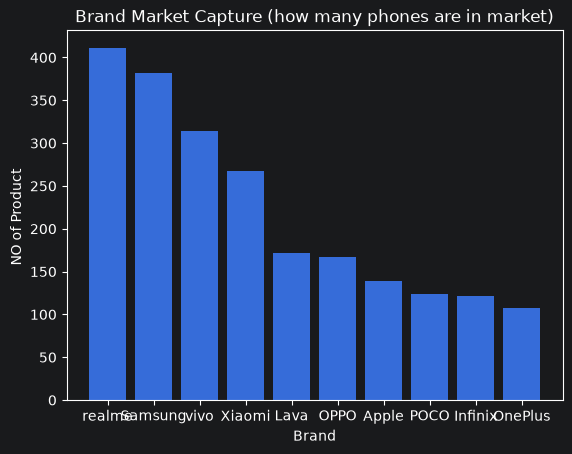

In [37]:
plt.bar(x=df['brand'].value_counts().head(10).index, height=df['brand'].value_counts().head(10).values)
plt.title("Brand Market Capture (how many phones are in market)")
plt.xlabel("Brand")
plt.ylabel("NO of Product ")
plt.show()

Text(0.5, 1.0, 'Pie Chart ')

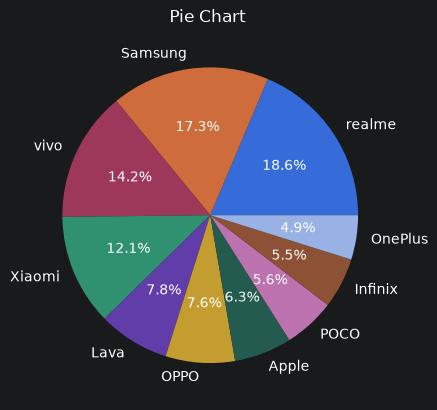

In [38]:
plt.pie(df['brand'].value_counts().head(10), autopct='%1.1f%%', labels=df['brand'].value_counts().head(10).index)
plt.title("Pie Chart ")

## Price

In [40]:
df['Price'].describe()

count      3545.000000
mean      26570.296192
std       29494.676541
min        1805.000000
25%        9999.000000
50%       16999.000000
75%       29999.000000
max      259999.000000
Name: Price, dtype: float64

In [43]:
df[df['Price'] == 259999]

,brand,model,Price,price_tier,processor_brand,processor,ram,storage_capacity,primary_rear_camera,camera_count,front_camera,battery_capacity,charging_type,display_type,display_size,antutu_score
459,Samsung,Samsung Galaxy Z Fold 8 Ultra 1TB 16GB RAM,259999,Ultra-Premium Tier,Snapdragon,Snapdragon 8 Elite Gen 5,16.0,1.0,200.0,3,10.0,5000,45.0,AMOLED,8.0,3074056.0
